#### Stochastic Simulation Project 1
Sophia Reiffenstein Petersen (s224222)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import random
import pandas as pd
from functions_project1 import *

#### Part 1

Average time until death: 265.04 months
maximum time until death: 1151 months
minimum time until death: 1 months
95% confidence interval for the average time until death: (253.60, 276.47) months


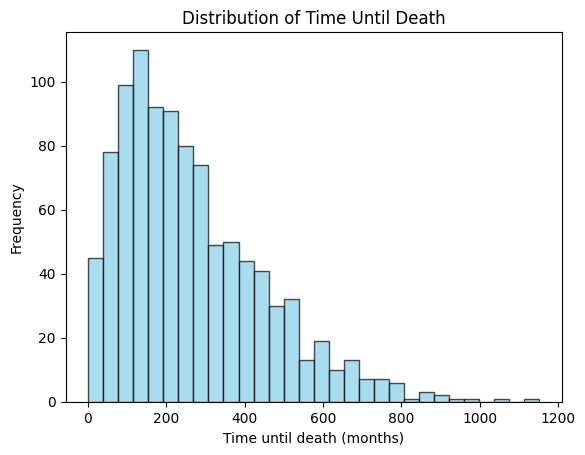

In [2]:
## Task 1
np.random.seed(42) 
n_women = 1000
death_times = cancer_simulation_women(n_women)

print(f"Average time until death: {np.mean([time for time, _ in death_times]):.2f} months")
print(f"maximum time until death: {np.max([time for time, _ in death_times])} months")
print(f"minimum time until death: {np.min([time for time, _ in death_times])} months")

lower_bound, upper_bound = conf_interval([time for time, _ in death_times])
print(f"95% confidence interval for the average time until death: ({lower_bound:.2f}, {upper_bound:.2f}) months")

plt.hist([time for time, _ in death_times], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Time Until Death')
plt.xlabel('Time until death (months)')
plt.ylabel('Frequency')
plt.savefig('death_times_histogram.png')
plt.show()

In [3]:
proportion = proportion_local_recurrence(n_women)
print(f"Proportion of patients with local recurrence: {proportion:.4f}")

Proportion of patients with local recurrence: 0.5890


In [4]:
### Task 2

np.random.seed(42)
t = 120
p0 = np.array([1,0,0,0,0])
pt = p0 @ np.linalg.matrix_power(Probability_matrix, t)

print(f"Probability of being in each state after {t} months: {pt}")

# In your simulations, what is the distribution over the states at t = 120?

state_distribution = state_distribution_at_time_t(n_women, t)
print(f"Simulated distribution over states at t={t} months: {state_distribution}")

chi2_statistic, p_value = chi_square_test(state_distribution, pt)
print(f"Chi-square statistic: {chi2_statistic:.4f}, p-value: {p_value:.4f}")

Probability of being in each state after 120 months: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
Simulated distribution over states at t=120 months: [0.357 0.164 0.184 0.061 0.234]
Chi-square statistic: 0.0036, p-value: 1.0000


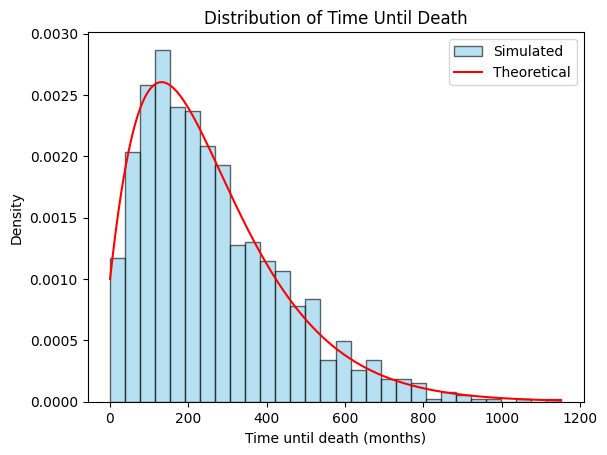

KS statistic: 0.0400, p-value: 0.4006


In [5]:
# Task 3
# lifetime distribution:
# P(T=t) = pi * (P_s)^t * ps
Ps = Probability_matrix[:4,:4]
ps = Probability_matrix[:4,4]
pi = p0[:4]

PT = np.zeros(max([time for time, _ in death_times]))
for t in range(1, len(PT)+1):
    PT[t-1] = pi @ np.linalg.matrix_power(Ps, t-1) @ ps

plt.hist([time for time, _ in death_times], bins=30, edgecolor='black', density=True, alpha=0.6, label='Simulated', color='skyblue')
plt.plot(range(1, len(PT)+1), PT/np.sum(PT), label='Theoretical', color='red')
plt.title('Distribution of Time Until Death')
plt.xlabel('Time until death (months)')
plt.ylabel('Density')
plt.legend()
plt.savefig('death_times_comparison.png')
plt.show()

ks_statistic, ks_p_value = stats.ks_2samp([time for time, _ in death_times], np.random.choice(range(1, max([time for time, _ in death_times])+1), size=1000, p=PT/np.sum(PT)))
print(f"KS statistic: {ks_statistic:.4f}, p-value: {ks_p_value:.4f}")

In [6]:
# Task 4
np.random.seed(42)
accepted_death_times = cancer_simulation_recurrence(1000)
mean_accepted_time = np.mean(accepted_death_times)

print(f"Estimated expected lifetime for women with recurrence within 12 months: {mean_accepted_time:.2f} months")

Estimated expected lifetime for women with recurrence within 12 months: 177.90 months


In [7]:
## Task 5
# Fraction that dies within first 350 months, simulating 200 women and doing it 100 times
np.random.seed(42)
avg_lifetimes = []
fractions = []

fractions = []
avg_lifetimes = []

for _ in range(100):
    death_times = cancer_simulation_women(200)
    times = [time for time, _ in death_times]

    fraction_dying_within_350 = np.mean([time <= 350 for time in times])
    
    fractions.append(fraction_dying_within_350)
    avg_lifetimes.append(np.mean(times))


print(f"Fraction of women dying within 350 months (mean over 100 simulations): {np.mean(fractions):.4f}")
conf_int_fraction = conf_interval(fractions)
print(f"95% confidence interval for the fraction dying within 350 months: [{conf_int_fraction[0]:.4f}, {conf_int_fraction[1]:.4f}]")

Fraction of women dying within 350 months (mean over 100 simulations): 0.7375
95% confidence interval for the fraction dying within 350 months: [0.7305, 0.7446]


In [8]:
X = np.array(avg_lifetimes)
Y = np.array(fractions)
c = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)

control_variate_estimate = control_variate(Y, X, c)
print(f"Adjusted fraction of women dying within 350 months (control variate): {np.mean(control_variate_estimate):.4f}")
conf_int_cv = conf_interval(control_variate_estimate)

print(f"95% confidence interval for the adjusted fraction: [{conf_int_cv[0]:.4f}, {conf_int_cv[1]:.4f}]")

variance_reduction = 100 * (np.var(Y, ddof=1) - np.var(control_variate_estimate, ddof=1)) / np.var(Y, ddof=1)
print(f"Variance reduction achieved by control variate: {variance_reduction:.3f}%")

Adjusted fraction of women dying within 350 months (control variate): 0.7376
95% confidence interval for the adjusted fraction: [0.7341, 0.7410]
Variance reduction achieved by control variate: 76.246%


# Part 2

In [ ]:
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001],[0, -0.014, 0.005, 0.004, 0.005],[0, 0, -0.008, 0.003, 0.005],[0, 0, 0, -0.009, 0.009],[0, 0, 0, 0, 0]])
states = []
ts = []
distant_reappearences = 0
for _ in range(1000):
    state = 0
    t = 0
    while state != 4:
        time_to_next = stats.expon.rvs(scale=-1/Q[state, state])
        if (t + time_to_next > 30.5 and t < 30.5) and (state == 2 or state == 3):
            distant_reappearences += 1
        t += time_to_next  
        transition_probs = Q[state] / -Q[state, state]
        # Remove probability of self-transition, and backwards transitions
        transition_probs[state] = 0
        transition_probs[:state] = 0
        transition_probs /= transition_probs.sum() # Renormalize
        state = np.random.choice(5, p=transition_probs)
        states.append(state)
    ts.append(t)
plt.hist(ts, bins=50, density=True)
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Continuous-Time Simulation)')
plt.show()

In [ ]:
# Report the mean, along with a confidence interval, and the standard deviation, also with a confidence interval.
mean_time = np.mean(ts)
std_time = np.std(ts, ddof=1)
n = len(ts)
confidence_level = 0.95
z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)
mean_ci_lower = mean_time - z_score * (std_time / np.sqrt(n))
mean_ci_upper = mean_time + z_score * (std_time / np.sqrt(n))
std_ci_lower = std_time * np.sqrt((n - 1) / stats.chi2.ppf(1 - (1 - confidence_level) / 2, n - 1))
std_ci_upper = std_time * np.sqrt((n - 1) / stats.chi2.ppf((1 - confidence_level) / 2, n - 1))
print(f'Mean Time to Absorption: {mean_time:.4f} (95% CI: [{mean_ci_lower:.4f}, {mean_ci_upper:.4f}])')
print(f'Standard Deviation of Time to Absorption: {std_time:.4f} (95% CI: [{std_ci_lower:.4f}, {std_ci_upper:.4f}])')
print(f'Estimated Probability of distant reappearance: {distant_reappearences/1000:.4f}')
print(f'Width of 95% CI for Mean Time to Absorption: {(mean_ci_upper - mean_ci_lower):.4f}')
print(f'Width of 95% CI for Standard Deviation: {(std_ci_upper - std_ci_lower):.4f}')

In [ ]:
def continuous_phase_type_pdf(p0, Qs, t) -> float:
    q0 = -Qs @ np.ones(Qs.shape[0])
    return float(p0 @ scipy.linalg.expm(Qs * t) @ q0)

In [ ]:
def continuous_phase_type_cdf(p0, Qs, t) -> float:
    ones = np.ones(Qs.shape[0])
    return float(1 - p0 @ scipy.linalg.expm(Qs * t) @ ones)

In [ ]:
plt.hist(ts, bins=50, density=True)
plt.plot(sorted(ts), [continuous_phase_type_pdf(np.array([1, 0, 0, 0]), Q[:4,:4], t) for t in sorted(ts)], color='red', label='Theoretical PDF')
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Continuous-Time Simulation)')
plt.legend()
plt.show()

In [ ]:
# statistical test for goodness of fit, using the Kolmogorov-Smirnov test
def cdf(x):
    return np.array([continuous_phase_type_cdf(np.array([1, 0, 0, 0]), Q[:4,:4], t) for t in x])

ks_statistic, p_value = stats.kstest(ts, cdf)
print(f'KS Statistic: {ks_statistic:.4f}, p-value: {p_value:.4f}')

In [ ]:
Q_treatment = np.array([[-0.00475 ,0.0025, 0.00125, 0, 0.001], [0 ,-0.007, 0.002, 0.005, 0],[0, 0, -0.008, 0.003, 0.005], [0,0,0,-0.009,0.009],[0, 0, 0, 0, 0]])
Q_treatment

In [ ]:
ts_treatment = []
for _ in range(1000):
    state = 0
    t = 0
    while state != 4:
        time_to_next = stats.expon.rvs(scale=-1/Q_treatment[state, state])
        t += time_to_next  
        transition_probs = Q_treatment[state] / -Q_treatment[state, state]
        # Remove probability of self-transition, and backwards transitions
        transition_probs[state] = 0
        transition_probs[:state] = 0
        transition_probs /= transition_probs.sum() # Renormalize
        state = np.random.choice(5, p=transition_probs)
        ts_treatment.append(t)

In [ ]:
plt.hist(ts_treatment, bins=50, density=True)
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Treatment Simulation)')
plt.show()

In [ ]:
# kaplan-meier estimator for the survival function
def kaplan_meier(t, t_list):
    n = len(t_list)
    at_risk = n
    survival_prob = 1.0
    for time in sorted(t_list):
        if time <= t:
            survival_prob *= (at_risk - 1) / at_risk
            at_risk -= 1
        else:
            break
    return survival_prob

In [ ]:
plt.plot(sorted(ts_treatment), [kaplan_meier(t, ts_treatment) for t in sorted(ts_treatment)], label='Kaplan-Meier Estimate')
plt.plot(sorted(ts), [kaplan_meier(t, ts) for t in sorted(ts)], label='Kaplan-Meier Estimate (No Treatment)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Estimator')
plt.legend()
plt.show()

In [ ]:
logrank_result = stats.logrank(ts_treatment, ts)
logrank_statistic, logrank_p_value = logrank_result.statistic, logrank_result.pvalue
print(f'Log-Rank Statistic: {logrank_statistic:.4f}, p-value: {logrank_p_value}')

# Part 3

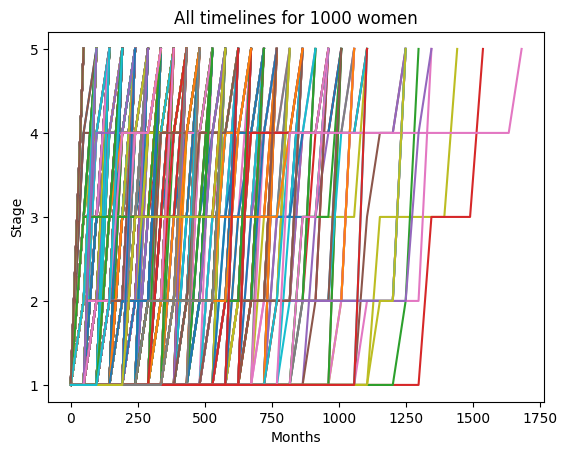

In [1]:
import matplotlib.pyplot as plt
import numpy as np

newq = np.array([[0,0.0025,0.00125,0,0.001],[0,0,0,0.002,0.005],[0,0,0,0.003,0.005],[0,0,0,0,0.009],[0,0,0,0,0]])
def rate(oldstatus):
    return np.random.exponential(1/np.sum(newq[oldstatus,:][oldstatus+1:]))

for womanidx in range(1000):
    timesteps = [0]
    xs = [0]

    currstate = 0
    nextevent = rate(currstate)
    while True:
        timestep = nextevent

        while timesteps[-1]+48<timestep:
            timesteps.append(48+timesteps[-1])
            xs.append(currstate)

        currstate = np.random.choice(range(currstate+1,5),p=(newq[currstate,:]/np.sum(newq[currstate,:][currstate+1:]))[currstate+1:])
        if currstate == 4:
            timesteps.append(48+timesteps[-1])
            xs.append(currstate) 
            break
        else:
            nextevent = timestep+rate(currstate)
    plt.plot(timesteps,np.array(xs)+1)

plt.title("All timelines for 1000 women")
plt.yticks([1,2,3,4,5])
plt.ylabel("Stage")
plt.xlabel("Months")
plt.show()